## **Processing Raw Dataset to Processed Dataset**

In [1]:
import cv2
import os
import shutil
import numpy as np
from ultralytics import YOLO

def process_subject_folder_to_silhouettes(
    input_folder="new raw dataset/Ankit", 
    output_folder="live_test_folder", 
    img_size=(64, 64),
    
    # === TWEAK THESE PARAMETERS ===
    inference_size=1080,        # Increase to 1280 or 1920 for maximum sharpness (runs slower)
    confidence_threshold=0.8,   # Increase to 0.6 or 0.7 for stricter, cleaner edges
    extract_every_n_frame=3     # 1 = 30 FPS, 2 = 15 FPS, 3 = 10 FPS, 6 = 5 FPS
    # ==============================
):
    # 1. Clean and prepare the output folder once
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(output_folder)
    
    # 2. Load the YOLO model once for all videos
    print("Loading YOLOv8 Segmentation Model...")
    model = YOLO("yolov8n-seg.pt")
    
    total_saved_count = 0
    
    # 3. Iterate through every file in the subject's folder
    valid_extensions = ('.mp4', '.avi', '.mov', '.mkv')
    video_files = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_extensions)]
    
    if not video_files:
        print(f"No video files found in {input_folder}")
        return

    print(f"Found {len(video_files)} videos in '{input_folder}'. Starting processing...\n")

    for video_name in video_files:
        video_path = os.path.join(input_folder, video_name)
        video_base_name = os.path.splitext(video_name)[0] # Get name without extension
        
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open {video_path}. Skipping.")
            continue
            
        frame_count = 0
        video_saved_count = 0
        print(f"Processing '{video_name}'...")

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: 
                break
                
            frame_count += 1
            
            # Frame Skipping Logic
            if frame_count % extract_every_n_frame != 0:
                continue
            
            # YOLO Inference
            results = model.predict(
                frame, 
                classes=[0], 
                retina_masks=True, 
                imgsz=inference_size, 
                conf=confidence_threshold,
                verbose=False
            )
            
            binary_silhouette = np.zeros((frame.shape[0], frame.shape[1]), dtype=np.uint8)
            
            for r in results:
                if r.masks is not None:
                    mask_data = r.masks.data[0].cpu().numpy()
                    binary_silhouette = np.maximum(binary_silhouette, (mask_data > 0.5).astype(np.uint8) * 255)

            if np.sum(binary_silhouette) > 0:
                x, y, w, h = cv2.boundingRect(binary_silhouette)
                
                pad_w = int(w * 0.10)
                pad_h = int(h * 0.10)
                
                x1 = max(x - pad_w, 0)
                y1 = max(y - pad_h, 0)
                x2 = min(x + w + pad_w, frame.shape[1])
                y2 = min(y + h + pad_h, frame.shape[0])
                
                cropped_person = binary_silhouette[y1:y2, x1:x2]
                final_silhouette = cv2.resize(cropped_person, img_size)
                
                # Save with a smart name: videoName_frame_0001.png
                save_filename = f"{video_base_name}_frame_{video_saved_count:04d}.png"
                save_path = os.path.join(output_folder, save_filename)
                
                cv2.imwrite(save_path, final_silhouette)
                video_saved_count += 1
                total_saved_count += 1

        cap.release()
        print(f"  -> Extracted {video_saved_count} silhouettes from '{video_name}'.")

    print(f"\n[SUCCESS] Finished folder! Extracted a total of {total_saved_count} silhouettes to '{output_folder}'.")

if __name__ == "__main__":
    current_dir = os.getcwd()
    
    # Point this to the folder containing all videos of the subject
    absolute_input_folder = os.path.join(current_dir, r"D:\Study\Coding\Project\GAIT_2\New Dataset\raw dataset", "Aditi") 
    absolute_output_folder = os.path.join(current_dir, r"D:\Study\Coding\Project\GAIT_2\New Dataset\processed\Aditi")
    
    process_subject_folder_to_silhouettes(
        input_folder=absolute_input_folder, 
        output_folder=absolute_output_folder, 
        img_size=(64, 64),
        inference_size=1080,       
        extract_every_n_frame=2    
    )

Loading YOLOv8 Segmentation Model...
Found 10 videos in 'D:\Study\Coding\Project\GAIT_2\New Dataset\raw dataset\Aditi'. Starting processing...

Processing 'WhatsApp Video 2026-03-23 at 4.29.37 PM.mp4'...
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max stride 32, updating to [1088]
WARNING imgsz=[1080] must be multiple of max s

## **Splitting Processed Dataset into train and validation**

In [2]:
import os
import shutil
import random
from collections import defaultdict

def reorganize_dataset(source_root, output_root, validation_split=0.3, random_seed=42):
    """
    CUSTOM DATASET VERSION
    
    Reorganize custom dataset by:
    - Reading all subject folders (regardless of name/number)
    - Splitting images into train/validation (30% validation, 70% training)
    - Organizing by person folder
    - No overlapping between splits
    """

    random.seed(random_seed)

    # Create output directories
    train_root = os.path.join(output_root, 'train')
    validation_root = os.path.join(output_root, 'validation')

    os.makedirs(train_root, exist_ok=True)
    os.makedirs(validation_root, exist_ok=True)

    print(f"Source root: {source_root}")
    print(f"Output root: {output_root}")
    print(f"Validation split: {validation_split * 100}%")
    print("-" * 60)
    print()

    # Get all person folders (Removed the .isdigit() constraint)
    all_items = os.listdir(source_root)
    person_folders = sorted([
        item for item in all_items 
        if os.path.isdir(os.path.join(source_root, item))
    ])

    print(f"Found {len(person_folders)} subject folders: {', '.join(person_folders)}")
    print("-" * 60)
    print()

    # Dictionary to store all images per person
    person_images = defaultdict(list)

    # Walk through each person folder
    for person_name in person_folders:
        person_path = os.path.join(source_root, person_name)

        # Collect all images from this person 
        for root, dirs, files in os.walk(person_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    full_path = os.path.join(root, file)
                    person_images[person_name].append(full_path)

    # Print summary
    total_images = sum(len(images) for images in person_images.values())
    if total_images == 0:
        print("ERROR: No images found! Please check your source_root path.")
        return None, None
        
    print(f"Total images collected: {total_images:,}")
    print(f"Subjects with images: {len(person_images)}")
    print()
    print("Processing and splitting images:")
    print("-" * 60)

    # Process each person's images
    stats = {'train': 0, 'validation': 0, 'persons_processed': 0}

    for person_name in sorted(person_images.keys()):
        images = person_images[person_name]
        num_images = len(images)

        if num_images == 0:
            continue

        # Randomly shuffle images for this person
        random.shuffle(images)

        # Calculate split point
        split_point = int(num_images * validation_split)

        # Note: validation takes the first portion, train takes the rest
        validation_images = images[:split_point]
        train_images = images[split_point:]

        # Create person folders in train and validation directories
        train_person_dir = os.path.join(train_root, person_name)
        validation_person_dir = os.path.join(validation_root, person_name)

        os.makedirs(train_person_dir, exist_ok=True)
        os.makedirs(validation_person_dir, exist_ok=True)

        # Copy images to train folder
        for img_path in train_images:
            filename = os.path.basename(img_path)
            dest_path = os.path.join(train_person_dir, filename)
            shutil.copy2(img_path, dest_path)
            stats['train'] += 1

        # Copy images to validation folder
        for img_path in validation_images:
            filename = os.path.basename(img_path)
            dest_path = os.path.join(validation_person_dir, filename)
            shutil.copy2(img_path, dest_path)
            stats['validation'] += 1

        stats['persons_processed'] += 1

        # Print progress for each person
        val_count = len(validation_images)
        train_count = len(train_images)
        val_pct = (val_count / num_images) * 100 if num_images > 0 else 0

        print(f"Subject '{person_name}': Total={num_images:6,d} | Train={train_count:6,d} | Val={val_count:6,d} ({val_pct:.1f}%)")

    # Print summary statistics
    print()
    print("=" * 60)
    print("REORGANIZATION COMPLETE")
    print("=" * 60)
    print(f"Subjects processed: {stats['persons_processed']}")
    print(f"Total images in training: {stats['train']:,}")
    print(f"Total images in validation: {stats['validation']:,}")
    print(f"Total images processed: {stats['train'] + stats['validation']:,}")

    if stats['train'] + stats['validation'] > 0:
        actual_val_pct = (stats['validation'] / (stats['train'] + stats['validation'])) * 100
        print(f"Actual validation split: {actual_val_pct:.2f}%")

    print()
    print(f"Train directory: {train_root}")
    print(f"Validation directory: {validation_root}")
    print()

    return train_root, validation_root


if __name__ == "__main__":
    # Ensure these paths match your system
    SOURCE_DATASET = r"D:\Study\Coding\Project\GAIT_2\New Dataset\processed"
    OUTPUT_DIRECTORY = r"D:\Study\Coding\Project\GAIT_2\New Dataset"

    train_dir, val_dir = reorganize_dataset(
        source_root=SOURCE_DATASET,
        output_root=OUTPUT_DIRECTORY,
        validation_split=0.3, # 30% for validation, 70% for training
        random_seed=42
    )

Source root: D:\Study\Coding\Project\GAIT_2\New Dataset\processed
Output root: D:\Study\Coding\Project\GAIT_2\New Dataset
Validation split: 30.0%
------------------------------------------------------------

Found 10 subject folders: Adarsh, Aditi, Aman, Ankit, Himanshu, Jyotibrat, Kunal, Swayam, Tiwari, Ujjwal
------------------------------------------------------------

Total images collected: 7,668
Subjects with images: 10

Processing and splitting images:
------------------------------------------------------------
Subject 'Adarsh': Total=   716 | Train=   502 | Val=   214 (29.9%)
Subject 'Aditi': Total=   639 | Train=   448 | Val=   191 (29.9%)
Subject 'Aman': Total=   870 | Train=   609 | Val=   261 (30.0%)
Subject 'Ankit': Total=   796 | Train=   558 | Val=   238 (29.9%)
Subject 'Himanshu': Total=   741 | Train=   519 | Val=   222 (30.0%)
Subject 'Jyotibrat': Total=   866 | Train=   607 | Val=   259 (29.9%)
Subject 'Kunal': Total=   712 | Train=   499 | Val=   213 (29.9%)
Subjec

## **Training Xception model**

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import os
import time
import json
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

# === UPDATE THIS TO YOUR NEW DATASET FOLDER ===
# This should be the folder that contains your 'train' and 'validation' folders
DATA_DIR = r"D:\Study\Coding\Project\GAIT_2\New Dataset" 

BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 0.001

def train_gait_model():
    print(f"Initializing custom training process...")

    # --- Set up Data Transformations ---
    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
        'validation': transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]),
    }

    # --- Load the Datasets ---
    train_dir = os.path.join(DATA_DIR, 'train')
    validation_dir = os.path.join(DATA_DIR, 'validation')

    print(f"Loading data from: {DATA_DIR}")
    
    train_dataset = datasets.ImageFolder(train_dir, data_transforms['train'])
    val_dataset = datasets.ImageFolder(validation_dir, data_transforms['validation'])

    # Dynamically figure out how many subjects you have based on folders
    class_names = train_dataset.classes
    num_classes = len(class_names)
    print(f"\nFound {num_classes} subjects: {class_names}")

    # --- CRITICAL: Save the class mapping for real-time testing later ---
    mapping_path = 'class_mapping.json'
    with open(mapping_path, 'w') as f:
        json.dump(train_dataset.class_to_idx, f)
    print(f"Saved class mapping to {mapping_path}")

    # --- Create DataLoaders ---
    # Note: I reduced num_workers to 4. 8 often causes BrokenPipeErrors on Windows laptops.
    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True),
        'validation': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    }

    dataset_sizes = {'train': len(train_dataset), 'validation': len(val_dataset)}
    print(f"Training images: {dataset_sizes['train']}")
    print(f"Validation images: {dataset_sizes['validation']}\n")

    # --- Build the Xception Model using TIMM ---
    # This automatically loads ImageNet weights and changes the final layer to match your num_classes
    print("Loading Xception model via TIMM...")
    model = timm.create_model('xception', pretrained=True, num_classes=num_classes)

    # --- Set up for Training ---
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Training will use device: {device}\n")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    scaler = GradScaler()
    use_amp = torch.cuda.is_available()

    # ---> ADDED: Initialize history dictionary <---
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # --- Start the Training Loop ---
    start_time = time.time()
    
    for epoch in range(NUM_EPOCHS):
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
        print('-' * 10)

        for phase in ['train', 'validation']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            progress_bar = tqdm(dataloaders[phase], desc=f'{phase.capitalize()} Phase')
            
            for inputs, labels in progress_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad(set_to_none=True)

                with autocast(enabled=use_amp):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}\n')

            # ---> ADDED: Save metrics to history <---
            acc_value = epoch_acc.item() # convert PyTorch tensor to standard python float
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(acc_value)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(acc_value)

    time_elapsed = time.time() - start_time
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    
    # --- Save the Custom Model ---
    model_save_path = f'new_dataset_gait_xception_FULL.pth'
    torch.save(model, model_save_path)
    print(f"Entire model saved successfully to '{model_save_path}'")

    # ---> ADDED: Save history to JSON file <---
    history_file = 'training_history.json'
    with open(history_file, 'w') as f:
        json.dump(history, f)
    print(f"Training history saved permanently to '{history_file}'")
    
    return history # Returns it just in case you want to use it immediately in the next cell

if __name__ == '__main__':
    # We assign the output to 'history' so it stays in memory after running
    history = train_gait_model()

d:\Study\Coding\Project\venv\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
d:\Study\Coding\Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing custom training process...
Loading data from: D:\Study\Coding\Project\GAIT_2\New Dataset

Found 10 subjects: ['Adarsh', 'Aditi', 'Aman', 'Ankit', 'Himanshu', 'Jyotibrat', 'Kunal', 'Swayam', 'Tiwari', 'Ujjwal']
Saved class mapping to class_mapping.json
Training images: 7275
Validation images: 4410

Loading Xception model via TIMM...


d:\Study\Coding\Project\venv\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
C:\Users\swaya\AppData\Local\Temp\ipykernel_31080\1783407779.py:82: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Training will use device: cuda:0

Epoch 1/20
----------


Train Phase:   0%|          | 0/114 [00:00<?, ?it/s]C:\Users\swaya\AppData\Local\Temp\ipykernel_31080\1783407779.py:111: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Train Phase: 100%|██████████| 114/114 [00:22<00:00,  5.00it/s]


...

Validation Loss: 0.0501 Acc: 0.9884

Epoch 20/20
----------


Train Phase: 100%|██████████| 114/114 [00:23<00:00,  4.82it/s]


Train Loss: 0.0480 Acc: 0.9856



Validation Phase: 100%|██████████| 69/69 [00:14<00:00,  4.75it/s]

Validation Loss: 0.0455 Acc: 0.9857

Training complete in 12m 5s
Entire model saved successfully to 'new_dataset_gait_xception_FULL.pth'
Training history saved permanently to 'training_history.json'


## **Visualisations**

Graph saved successfully as 'training_curves.png'


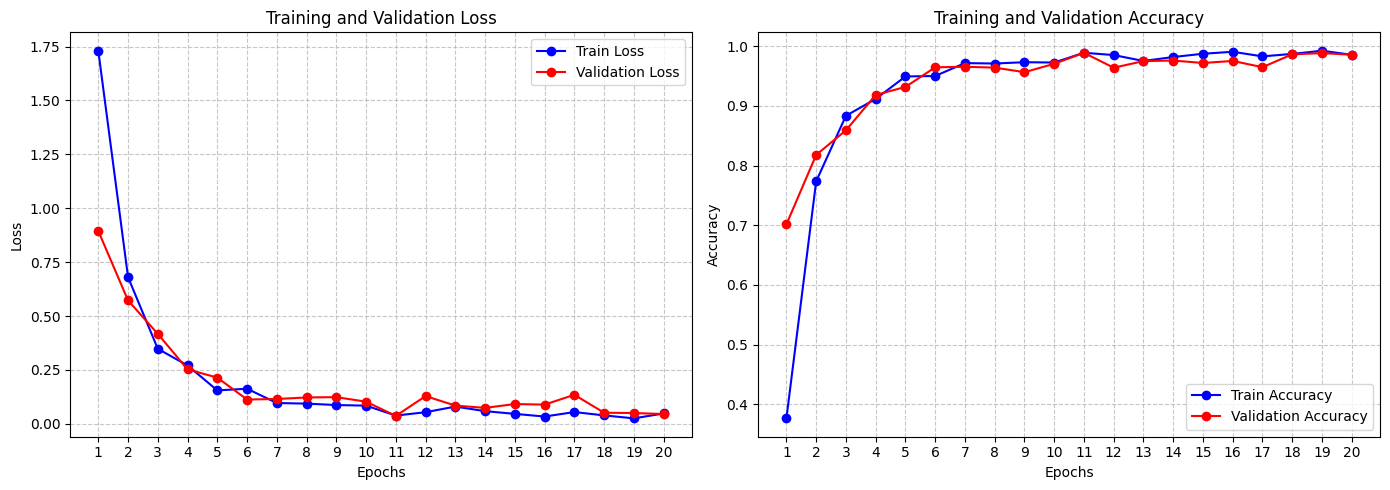

In [4]:
import json
import matplotlib.pyplot as plt

# 1. Load the saved history from the JSON file
with open('training_history.json', 'r') as f:
    history = json.load(f)

# Calculate the number of epochs dynamically based on the data
epochs = range(1, len(history['train_loss']) + 1)

# 2. Set up the plotting canvas
plt.figure(figsize=(14, 5))

# --- Plot 1: Training vs Validation Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(epochs, history['val_loss'], label='Validation Loss', color='red', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs) # Forces the x-axis to show whole numbers
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Training vs Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy', color='red', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Save the graph as an image and display it
plt.tight_layout()
plt.savefig('training_curves.png')
print("Graph saved successfully as 'training_curves.png'")

plt.show()

[SYSTEM] Using device: cuda:0

[SYSTEM] Analyzing validation data and generating heatmap... Please wait.


C:\Users\swaya\AppData\Local\Temp\ipykernel_31080\986544351.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('Models/new_dataset_gait_xception_FULL.pt

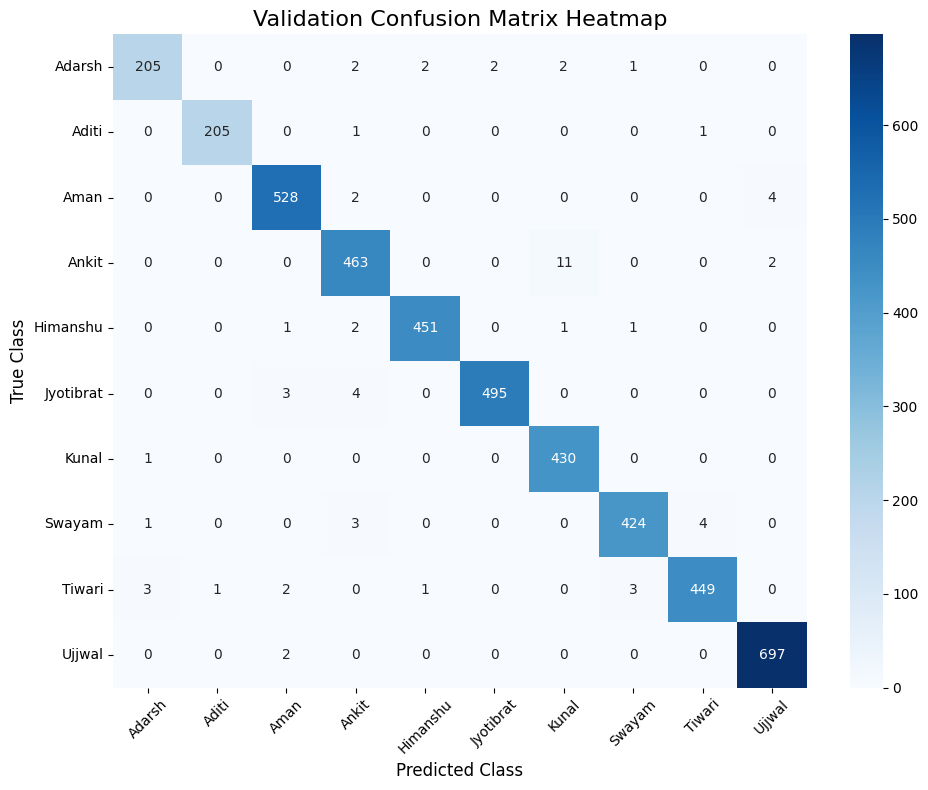

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# --- NEW IMPORTS FOR THE HEATMAP ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. THE HEATMAP GENERATOR FUNCTION
# ==========================================
def generate_heatmap(model, dataloader, device, class_names):
    print("\n[SYSTEM] Analyzing validation data and generating heatmap... Please wait.")
    model.eval() # Freeze model weights for inference
    
    all_preds = []
    all_labels = []

    # Iterate through the validation data
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot the matrix using Seaborn
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Validation Confusion Matrix Heatmap', fontsize=16)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. THE MAIN EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # Set up device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"[SYSTEM] Using device: {device}")

    # Load the trained model
    model = torch.load('Models/new_dataset_gait_xception_FULL.pth', map_location=device)
    model = model.to(device)

    # Set up validation data transforms
    data_transforms = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    validation_dir = r"D:\Study\Coding\Project\GAIT_2\New Dataset\validation"
    val_dataset = datasets.ImageFolder(validation_dir, data_transforms)
    
    # Note: On Windows, num_workers > 0 can sometimes cause freezing. 
    # If it hangs, change num_workers=0.
    dataloaders_val = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

    # Extract the class names dynamically from your folders
    my_class_names = val_dataset.classes

    # Now generate the heatmap!
    generate_heatmap(model, dataloaders_val, device, my_class_names)

Loading model on cuda:0...
Evaluating validation images for ROC curve...


C:\Users\swaya\AppData\Local\Temp\ipykernel_31080\1835569744.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('Models/new_dataset_gait_xception_FULL.p

Success! Graph saved as 'roc_auc_curve.png'


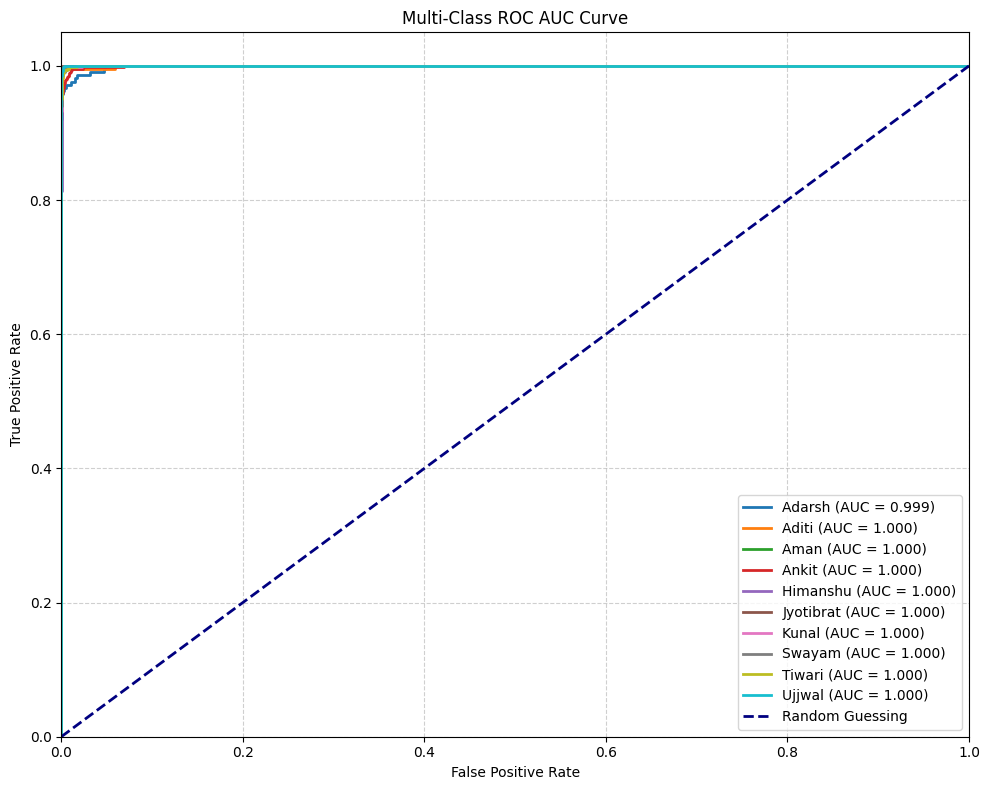

In [12]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
import json

def generate_roc_auc_curve():
    # 1. Recreate the Validation DataLoader
    DATA_DIR = r"D:\Study\Coding\Project\GAIT_2\New Dataset"
    validation_dir = os.path.join(DATA_DIR, 'validation')
    
    val_transforms = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    
    val_dataset = datasets.ImageFolder(validation_dir, val_transforms)
    val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)

    # 2. Load your saved model and class names
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Loading model on {device}...")
    
    model = torch.load('Models/new_dataset_gait_xception_FULL.pth', map_location=device)
    model.to(device)
    model.eval() # CRITICAL for evaluation

    try:
        with open('class_mapping.json', 'r') as f:
            class_map = json.load(f)
            class_names = [k for k, v in sorted(class_map.items(), key=lambda item: item[1])]
    except FileNotFoundError:
        class_names = val_dataset.classes

    num_classes = len(class_names)

    # 3. Gather predictions
    print("Evaluating validation images for ROC curve...")
    y_true = []
    y_scores = []

    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            # Convert raw outputs to percentage probabilities
            probabilities = F.softmax(outputs, dim=1)
            
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probabilities.cpu().numpy())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    # 4. Prepare data for Multi-Class ROC
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    if num_classes == 2:
        y_true_bin = np.hstack((1 - y_true_bin, y_true_bin))

    # 5. Plot the ROC Curve
    plt.figure(figsize=(10, 8))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    # Plot the random guessing line
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC AUC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig('roc_auc_curve.png')
    print("Success! Graph saved as 'roc_auc_curve.png'")
    
    plt.show()

# Run it!
generate_roc_auc_curve()

## **Majority Voting Testing**

In [13]:
import torch
from torchvision import transforms
from PIL import Image
from pathlib import Path
from collections import Counter
import json

def get_majority_vote(folder_path, model, device, class_names):
    folder_path = Path(folder_path)
    
    # Grab all images directly in this folder
    image_paths = list(folder_path.glob("*.png")) + list(folder_path.glob("*.jpg")) + list(folder_path.glob("*.jpeg"))

    if not image_paths:
        print(f"No images found in {folder_path}!")
        return None

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    predicted_indices = []

    # Run predictions on every image
    with torch.no_grad():
        for img_path in image_paths:
            img = Image.open(img_path).convert('RGB')
            tensor = transform(img).unsqueeze(0).to(device)
            
            outputs = model(tensor)
            _, pred = torch.max(outputs, 1)
            pred_idx = pred.item()
            predicted_indices.append(pred_idx)
            
            # Print the prediction for each individual image
            predicted_subject_name = class_names[pred_idx]
            print(f"Image {img_path.name} predicted as {predicted_subject_name}")

    if not predicted_indices:
        return None

    # Tally the votes
    counter = Counter(predicted_indices)
    most_common_idx, count = counter.most_common(1)[0]
    predicted_subject = class_names[most_common_idx]

    # Print the exact final summary format
    print(f"\nMost frequent predicted subject across folder: {predicted_subject} (predicted {count} times)")
    print(f"Final subject prediction: {predicted_subject}")
    
    return predicted_subject


def run_evaluation(model_path, test_directory):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Processing on: {device}")

    # 1. Load the Model
    try:
        model = torch.load(model_path, map_location=device, weights_only=False)
        model.to(device)
        model.eval()
    except FileNotFoundError:
        print(f"Error: Could not find '{model_path}'. Please check the path.")
        return

    # 2. Load Class Names
    try:
        with open('class_mapping.json', 'r') as f:
            class_map = json.load(f)
            class_names = [k for k, v in sorted(class_map.items(), key=lambda item: item[1])]
    except FileNotFoundError:
        print("Error: 'class_mapping.json' not found in the current directory.")
        return

    print("\n" + "="*50)
    print(f"Evaluating Folder: {test_directory}")
    print("="*50 + "\n")

    # 3. Run the voting function
    get_majority_vote(test_directory, model, device, class_names)

In [ ]:
# Insert your model file name/path
MODEL_PATH = "Models/new_dataset_gait_xception_FULL.pth"

# Insert the path to the folder containing your test images
TEST_FOLDER_PATH = r"D:\Study\Coding\Project\GAIT_2\New Dataset\test"

# Run the evaluation
run_evaluation(MODEL_PATH, TEST_FOLDER_PATH)

Processing on: cuda:0

Evaluating Folder: D:\Study\Coding\Project\GAIT_2\processed_subject_1

Image frame_0000.png predicted as Aditi
Image frame_0001.png predicted as Ujjwal
Image frame_0002.png predicted as Ujjwal
Image frame_0003.png predicted as Ujjwal
Image frame_0004.png predicted as Ujjwal
Image frame_0005.png predicted as Aman
Image frame_0006.png predicted as Aditi
Image frame_0007.png predicted as Ujjwal
Image frame_0008.png predicted as Aditi
Image frame_0009.png predicted as Aditi
Image frame_0010.png predicted as Aditi
Image frame_0011.png predicted as Aditi
Image frame_0012.png predicted as Aditi
Image frame_0013.png predicted as Aditi
Image frame_0014.png predicted as Aditi
Image frame_0015.png predicted as Aditi
Image frame_0016.png predicted as Aditi
Image frame_0017.png predicted as Aditi
Image frame_0018.png predicted as Aditi
Image frame_0019.png predicted as Aditi
Image frame_0020.png predicted as Aditi
Image frame_0021.png predicted as Aditi
Image frame_0022.png p

## **Capturing live subject, processing and storing the silhouettes**

In [17]:
import cv2
import time
import threading
import os
import shutil
import numpy as np
from ultralytics import YOLO

# ==========================================
# 1. THE PREPROCESSING FUNCTION (Extracts Silhouettes)
# ==========================================
def process_video_to_silhouettes_custom(
    video_path="temp_gait.avi", 
    output_folder="live_test_folder", 
    img_size=(64, 64),
    
    # === TWEAK THESE PARAMETERS ===
    inference_size=1080,        # Increase to 1280 or 1920 for maximum sharpness (runs slower)
    confidence_threshold=0.8,   # Increase to 0.6 or 0.7 for stricter, cleaner edges
    extract_every_n_frame=3     # 1 = 30 FPS, 2 = 15 FPS, 3 = 10 FPS, 6 = 5 FPS
    # ==============================
):
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(output_folder)
    
    print("Loading YOLOv8 Segmentation Model...")
    model = YOLO("yolov8n-seg.pt")
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open {video_path}")
        return
        
    frame_count = 0
    saved_count = 0
    print(f"Processing video with Inference Size: {inference_size}, saving every {extract_every_n_frame} frames...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: 
            break
            
        frame_count += 1
        
        # Frame Skipping Logic: If it's not the Nth frame, skip the AI processing entirely
        if frame_count % extract_every_n_frame != 0:
            continue
        
        # We pass your custom inference_size (imgsz) and confidence (conf) here
        results = model.predict(
            frame, 
            classes=[0], 
            retina_masks=True, 
            imgsz=inference_size, 
            conf=confidence_threshold,
            verbose=False
        )
        
        binary_silhouette = np.zeros((frame.shape[0], frame.shape[1]), dtype=np.uint8)
        
        for r in results:
            if r.masks is not None:
                mask_data = r.masks.data[0].cpu().numpy()
                binary_silhouette = np.maximum(binary_silhouette, (mask_data > 0.5).astype(np.uint8) * 255)

        if np.sum(binary_silhouette) > 0:
            x, y, w, h = cv2.boundingRect(binary_silhouette)
            
            pad_w = int(w * 0.10)
            pad_h = int(h * 0.10)
            
            x1 = max(x - pad_w, 0)
            y1 = max(y - pad_h, 0)
            x2 = min(x + w + pad_w, frame.shape[1])
            y2 = min(y + h + pad_h, frame.shape[0])
            
            cropped_person = binary_silhouette[y1:y2, x1:x2]
            final_silhouette = cv2.resize(cropped_person, img_size)
            
            save_path = os.path.join(output_folder, f"frame_{saved_count:04d}.png")
            cv2.imwrite(save_path, final_silhouette)
            saved_count += 1

    cap.release()
    print(f"\n[SUCCESS] Extracted {saved_count} perfectly spaced silhouettes to '{output_folder}'!")


# ==========================================
# 2. THE MAIN CAMERA ENGINE
# ==========================================
def auto_capture_always_on_threaded_720p():
    # 1. Force 720p Resolution (The Sweet Spot for Speed vs. Quality)
    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    #cap.set(cv2.CAP_PROP_AUTO_EXPOSURE, 0.25) 
    
    # Manually set the exposure. 
    # This is a logarithmic scale. -4 or -5 is usually the sweet spot. 
    # If it's still too bright, lower it to -6. If it's too dark, raise it to -3.
    #cap.set(cv2.CAP_PROP_EXPOSURE, -5)
    
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # ==========================================
    # THE HARDWARE AUTO-BENCHMARK
    # ==========================================
    print(f"\n[SYSTEM] Benchmarking camera hardware at {width}x{height}... Please wait 2 seconds.")
    start_time = time.time()
    for _ in range(20): 
        cap.read()
    elapsed_time = time.time() - start_time
    
    true_fps = 20 / elapsed_time
    print(f"[SYSTEM] Hardware benchmark complete. Actual Camera Speed: {true_fps:.1f} FPS")
    
    # Exactly 5 seconds of video
    frames_to_capture = int(true_fps * 5.0)    
    # Dynamic skip targeting ~10-15 FPS for the final model
    dynamic_skip = max(1, round(true_fps / 10.0))
    
    print(f"[SYSTEM] -> Setting capture limit to {frames_to_capture} frames.")
    print(f"[SYSTEM] -> Setting extraction skip rate to {dynamic_skip}.")
    # ==========================================
    
    # 2. Tripwire Dimensions (60% width, 100% height)
    zone_w = int(width * 0.60)
    zone_h = int(height * 1.0)
    zx1 = int((width - zone_w) / 2)
    zy1 = 0; zx2 = zx1 + zone_w; zy2 = height
    
    print("\n[SYSTEM] Loading fast Watcher model...")
    watcher_model = YOLO("yolov8n.pt")
    
    # 3. System States
    state = "WAITING"
    frames_captured = 0
    subject_counter = 1
    cooldown_frames = 0
    
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = None
    filename = ""

    print("\n[READY] Always-On System Live. Waiting for subject...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        display_frame = frame.copy()

        if state == "WAITING":
            if cooldown_frames > 0:
                cooldown_frames -= 1
                cv2.putText(display_frame, "PROCESSING PREVIOUS...", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
            else:
                results = watcher_model.predict(frame, classes=[0], verbose=False)
                person_in_zone = False

                for r in results:
                    for box in r.boxes:
                        px1, py1, px2, py2 = map(int, box.xyxy[0])
                        if not (px2 < zx1 or px1 > zx2 or py2 < zy1 or py1 > zy2):
                            person_in_zone = True
                            break

                cv2.rectangle(display_frame, (zx1, zy1), (zx2, zy2), (255, 0, 0), 2)
                cv2.putText(display_frame, "WAITING FOR SUBJECT...", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

                if person_in_zone:
                    print(f"\n[TRIGGER] Subject detected! Capturing for 5 seconds...")
                    state = "CAPTURING"
                    frames_captured = 0
                    filename = f"live_subject_{subject_counter}.avi"
                    out = cv2.VideoWriter(filename, fourcc, true_fps, (width, height))

        elif state == "CAPTURING":
            out.write(frame)
            frames_captured += 1
            
            cv2.rectangle(display_frame, (zx1, zy1), (zx2, zy2), (0, 0, 255), 4)
            cv2.putText(display_frame, f"CAPTURING: {frames_captured}/{frames_to_capture}", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

            if frames_captured >= frames_to_capture:
                print(f"[SUCCESS] Saved {filename}")
                out.release()
                
                folder_name = f"processed_subject_{subject_counter}"
                
                # The Thread gets the optimized 720p inference size
                worker = threading.Thread(
                    target=process_video_to_silhouettes_custom, 
                    kwargs={
                        "video_path": filename,
                        "output_folder": folder_name,
                        "img_size": (64, 64),
                        "inference_size": 720,  # <--- Matched to new camera resolution
                        "confidence_threshold": 0.7,
                        "extract_every_n_frame": dynamic_skip 
                    }
                )
                worker.start()
                
                subject_counter += 1
                state = "WAITING"
                cooldown_frames = int(true_fps) 

        cv2.imshow("Always-On Biometric Scanner", display_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    if out is not None: out.release()
    cv2.destroyAllWindows()

# ==========================================
# 3. RUN THE SYSTEM
# ==========================================
if __name__ == "__main__":
    auto_capture_always_on_threaded_720p()


[SYSTEM] Benchmarking camera hardware at 1280x720... Please wait 2 seconds.
[SYSTEM] Hardware benchmark complete. Actual Camera Speed: 6.1 FPS
[SYSTEM] -> Setting capture limit to 30 frames.
[SYSTEM] -> Setting extraction skip rate to 1.

[SYSTEM] Loading fast Watcher model...

[READY] Always-On System Live. Waiting for subject...

[TRIGGER] Subject detected! Capturing for 5 seconds...
[SUCCESS] Saved live_subject_1.avi
Loading YOLOv8 Segmentation Model...
Processing video with Inference Size: 720, saving every 1 frames...
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be mult

KeyboardInterrupt: 

## **Live testing**

In [ ]:
import cv2
import time
import threading
import os
import shutil
import numpy as np
from ultralytics import YOLO

# --- NEW IMPORTS FOR LOCAL AI ---
import torch
from torchvision import transforms
from PIL import Image
import json
import timm # Required because the model was built using TIMM

# ==========================================
# GLOBAL VARIABLES
# ==========================================
latest_prediction = {"text": "", "timestamp": 0}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
local_model = None  
CLASS_NAMES = {} # Will be populated dynamically from your JSON file

# ==========================================
# STEP 1: INITIALIZE THE BRAIN
# ==========================================
def load_local_model(weights_path=r"Models\new_dataset_gait_xception_FULL.pth", mapping_path="class_mapping.json"):
    global local_model, CLASS_NAMES
    print(f"\n[SYSTEM] Booting up Local PyTorch Brain on {device}...")
    
    # 1. Load your exact Class Mapping
    try:
        with open(mapping_path, 'r') as f:
            class_to_idx = json.load(f)
            # Reverse the dictionary so we can look up names by their ID numbers
            CLASS_NAMES = {v: k for k, v in class_to_idx.items()}
        print(f"[SUCCESS] Loaded {len(CLASS_NAMES)} authorized subjects from mapping.")
    except Exception as e:
        print(f"[FATAL ERROR] Could not load class_mapping.json: {e}")
        exit()

    # 2. Load the Model
    try:
        # Since you saved the FULL model in your training script, we load it entirely
        local_model = torch.load(weights_path, map_location=device)
        local_model.eval() # Freeze weights for testing
        print("[SUCCESS] Local AI is loaded and ready.")
    except Exception as e:
        print(f"[FATAL ERROR] Could not load .pth file: {e}")
        exit()

# ==========================================
# STEP 2: THE LOCAL PREDICTION & CLEANUP
# ==========================================
def local_predict_and_cleanup(folder_path, video_path):
    global latest_prediction, local_model
    print(f"\n[INFERENCE] Analyzing silhouettes in '{folder_path}' locally...")
    
    # Matches your exact training transforms!
    transform = transforms.Compose([
        transforms.Resize((64, 64)), # Changed to 72x72
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # 3 Channels
    ])
    
    all_predictions = []
    
    try:
        image_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
        
        if len(image_files) > 0:
            with torch.no_grad(): 
                for img_name in image_files:
                    img_path = os.path.join(folder_path, img_name)
                    # Convert to RGB because your training Normalize expects 3 channels
                    image = Image.open(img_path).convert('RGB') 
                    image_tensor = transform(image).unsqueeze(0).to(device)
                    
                    outputs = local_model(image_tensor)
                    probabilities = torch.nn.functional.softmax(outputs, dim=1)
                    confidence, predicted_class = torch.max(probabilities, 1)
                    
                    all_predictions.append((predicted_class.item(), confidence.item()))
            
            # --- THE MAJORITY VOTE ---
            if all_predictions:
                class_ids = [pred[0] for pred in all_predictions]
                most_frequent_id = max(set(class_ids), key=class_ids.count)
                
                matching_confs = [pred[1] for pred in all_predictions if pred[0] == most_frequent_id]
                avg_confidence = sum(matching_confs) / len(matching_confs)
                
                # Look up the real name from your JSON file
                predicted_name = CLASS_NAMES.get(most_frequent_id, "Unknown")
                
                latest_prediction["text"] = f"MATCH: {predicted_name} (Conf: {avg_confidence:.2f})"
                latest_prediction["timestamp"] = time.time()
                print(f"[INFERENCE SUCCESS] {latest_prediction['text']}")
                
        else:
            print("[INFERENCE ERROR] No silhouettes found in folder.")
            
    except Exception as e:
        print(f"[INFERENCE FAILED] Error during PyTorch math: {e}")

    print(f"[CLEANUP] Wiping temporary files for {folder_path}...")
    try:
        if os.path.exists(video_path): os.remove(video_path)
        if os.path.exists(folder_path): shutil.rmtree(folder_path)
        print("[CLEANUP] System storage cleared.")
    except Exception as e:
        print(f"[CLEANUP ERROR] Failed to delete files: {e}")

# ==========================================
# 3. THE YOLO EXTRACTOR
# ==========================================
def process_video_to_silhouettes_custom(video_path, output_folder, img_size=(64, 64), inference_size=720, confidence_threshold=0.8, extract_every_n_frame=3):
    if os.path.exists(output_folder): shutil.rmtree(output_folder)
    os.makedirs(output_folder)
    
    model = YOLO("yolov8n-seg.pt")
    cap = cv2.VideoCapture(video_path)
    frame_count = 0; saved_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame_count += 1
        if frame_count % extract_every_n_frame != 0: continue
        
        results = model.predict(frame, classes=[0], retina_masks=True, imgsz=inference_size, conf=confidence_threshold, verbose=False)
        binary_silhouette = np.zeros((frame.shape[0], frame.shape[1]), dtype=np.uint8)
        
        for r in results:
            if r.masks is not None:
                mask_data = r.masks.data[0].cpu().numpy()
                binary_silhouette = np.maximum(binary_silhouette, (mask_data > 0.5).astype(np.uint8) * 255)

        if np.sum(binary_silhouette) > 0:
            x, y, w, h = cv2.boundingRect(binary_silhouette)
            pad_w = int(w * 0.10); pad_h = int(h * 0.10)
            x1 = max(x - pad_w, 0); y1 = max(y - pad_h, 0)
            x2 = min(x + w + pad_w, frame.shape[1]); y2 = min(y + h + pad_h, frame.shape[0])
            
            cropped_person = binary_silhouette[y1:y2, x1:x2]
            
            # Resize the physical extraction to 72x72 to match your PyTorch architecture
            final_silhouette = cv2.resize(cropped_person, (64, 64))
            
            cv2.imwrite(os.path.join(output_folder, f"frame_{saved_count:04d}.png"), final_silhouette)
            saved_count += 1
    cap.release()

# ==========================================
# 4. THREAD MANAGER 
# ==========================================
def thread_pipeline_manager(video_filename, folder_name, skip_rate):
    process_video_to_silhouettes_custom(
        video_path=video_filename, output_folder=folder_name,
        img_size=(64, 64), inference_size=720,
        confidence_threshold=0.7, extract_every_n_frame=skip_rate
    )
    local_predict_and_cleanup(folder_name, video_filename)

# ==========================================
# 5. THE MAIN CAMERA ENGINE 
# ==========================================
def auto_capture_always_on_threaded_720p():
    global latest_prediction
    
    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    
    # Hardware Overrides (Adjust exposure if needed)
    #cap.set(cv2.CAP_PROP_AUTO_EXPOSURE, 0.25) 
    #cap.set(cv2.CAP_PROP_EXPOSURE, 1) 
    
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"\n[SYSTEM] Benchmarking camera hardware... Please wait 2 seconds.")
    start_time = time.time()
    for _ in range(20): cap.read()
    true_fps = 20 / (time.time() - start_time)
    
    frames_to_capture = int(true_fps * 5.0)    
    dynamic_skip = max(1, round(true_fps / 10.0))
    
    zone_w = int(width * 0.60); zone_h = int(height * 1.0)
    zx1 = int((width - zone_w) / 2)
    zy1 = 0; zx2 = zx1 + zone_w; zy2 = height
    
    print("\n[SYSTEM] Loading fast Watcher model...")
    watcher_model = YOLO("yolov8n.pt")
    
    state = "WAITING"
    frames_captured = 0; subject_counter = 1; cooldown_frames = 0
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = None; filename = ""

    print("\n[READY] Camera Live. Walk into frame...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        display_frame = frame.copy()

        if time.time() - latest_prediction["timestamp"] < 10.0:
            cv2.rectangle(display_frame, (30, 30), (700, 110), (0, 0, 0), -1)
            cv2.putText(display_frame, latest_prediction["text"], (50, 85), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

        if state == "WAITING":
            if cooldown_frames > 0:
                cooldown_frames -= 1
                cv2.putText(display_frame, "PROCESSING PREVIOUS...", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
            else:
                results = watcher_model.predict(frame, classes=[0], verbose=False)
                person_in_zone = False

                for r in results:
                    for box in r.boxes:
                        px1, py1, px2, py2 = map(int, box.xyxy[0])
                        if not (px2 < zx1 or px1 > zx2 or py2 < zy1 or py1 > zy2):
                            person_in_zone = True
                            break

                cv2.rectangle(display_frame, (zx1, zy1), (zx2, zy2), (255, 0, 0), 2)
                cv2.putText(display_frame, "WAITING FOR SUBJECT...", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

                if person_in_zone:
                    state = "CAPTURING"
                    frames_captured = 0
                    filename = f"live_subject_{subject_counter}.avi"
                    out = cv2.VideoWriter(filename, fourcc, true_fps, (width, height))

        elif state == "CAPTURING":
            out.write(frame)
            frames_captured += 1
            
            cv2.rectangle(display_frame, (zx1, zy1), (zx2, zy2), (0, 0, 255), 4)
            cv2.putText(display_frame, f"CAPTURING: {frames_captured}/{frames_to_capture}", (zx1 + 10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

            if frames_captured >= frames_to_capture:
                out.release()
                folder_name = f"processed_subject_{subject_counter}"
                
                worker = threading.Thread(target=thread_pipeline_manager, args=(filename, folder_name, dynamic_skip))
                worker.start()
                
                subject_counter += 1
                state = "WAITING"
                cooldown_frames = int(true_fps) 

        cv2.imshow("Always-On Biometric Scanner", display_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

    cap.release()
    if out is not None: out.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    # Ensure these files are in the same folder as this script!
    load_local_model(
        weights_path=r"Models\new_dataset_gait_xception_FULL.pth", 
        mapping_path="class_mapping.json"
    ) 
    auto_capture_always_on_threaded_720p()


[SYSTEM] Booting up Local PyTorch Brain on cuda...
[SUCCESS] Loaded 10 authorized subjects from mapping.
[SUCCESS] Local AI is loaded and ready.


C:\Users\swaya\AppData\Local\Temp\ipykernel_22848\3536332580.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  local_model = torch.load(weights_path, map_location=device)


[SYSTEM] Benchmarking camera hardware... Please wait 2 seconds.

[SYSTEM] Loading fast Watcher model...

[READY] Camera Live. Walk into frame...
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 32, updating to [736]
WARNING imgsz=[720] must be multiple of max stride 

KeyboardInterrupt: 